In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 数据目录 - 使用新的高 block num 目录
LOG_DIR = "/home/bxb1/vllm_workbench/vllm/new-logs/project-granuality-tests-high-block-num-2"

def parse_folder_name(folder_name):
    """从文件夹名中提取所有配置参数"""
    pp_match = re.search(r'\{pp=(\d+-\d+)\}', folder_name)
    rr_match = re.search(r'\{rr=([\d.]+)\}', folder_name)
    blk_match = re.search(r'\{blk=(\d+)\}', folder_name)
    mig_match = re.search(r'\{mig=(\d+)\}', folder_name)
    vmm_match = re.search(r'\{vmm=(\d+)\}', folder_name)
    
    if pp_match and rr_match and blk_match:
        return {
            'pp_config': pp_match.group(1),
            'request_rate': float(rr_match.group(1)),
            'block_size': int(blk_match.group(1)),
            'migration': int(mig_match.group(1)) if mig_match else 0,
            'vmm': int(vmm_match.group(1)) if vmm_match else 1
        }
    return None

def parse_benchmark_log(filepath):
    """从benchmark.log末尾提取metrics: TTFT, Throughput, Normalized Latency"""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        
        metrics = {}
        
        # 使用正则表达式提取metrics
        ttft_match = re.search(r'Mean TTFT \(ms\):\s+([\d.]+)', content)
        throughput_match = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', content)
        normalized_latency_match = re.search(r'Mean Normalized Latency \(ms/tok\):\s+([\d.]+)', content)
        
        if ttft_match:
            metrics['ttft'] = float(ttft_match.group(1))
        if throughput_match:
            metrics['throughput'] = float(throughput_match.group(1))
        if normalized_latency_match:
            metrics['normalized_latency'] = float(normalized_latency_match.group(1))
            
        return metrics if len(metrics) == 3 else None
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return None

def parse_timestamp_metrics(filepath):
    """从timestamp_metrics.csv提取KV wastage (1 - actual/allocated 的平均值)"""
    try:
        df = pd.read_csv(filepath)
        # 过滤掉 allocated=0 的行（避免除零）
        df_valid = df[df['allocated_kv_memory_bytes'] > 0]
        
        if len(df_valid) == 0:
            return None
        
        # 计算 wastage: 1 - actual/allocated
        df_valid = df_valid.copy()
        df_valid['kv_memory_wastage'] = 1 - (
            df_valid['actual_kv_memory_bytes'] / df_valid['allocated_kv_memory_bytes']
        )
        
        return {
            'kv_memory_wastage': df_valid['kv_memory_wastage'].mean(),
            'kv_wastage_std': df_valid['kv_memory_wastage'].std(),
            'actual_kv_mean': df_valid['actual_kv_memory_bytes'].mean(),
            'allocated_kv_mean': df_valid['allocated_kv_memory_bytes'].mean()
        }
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return None

# 收集所有数据
data = []
for folder in os.listdir(LOG_DIR):
    folder_path = os.path.join(LOG_DIR, folder)
    if os.path.isdir(folder_path):
        benchmark_file = os.path.join(folder_path, "benchmark.log")
        timestamp_file = os.path.join(folder_path, "timestamp_metrics.csv")
        
        if os.path.exists(benchmark_file):
            config = parse_folder_name(folder)
            if config:
                metrics = parse_benchmark_log(benchmark_file)
                if metrics:
                    row = {**config, **metrics}
                    
                    # 尝试解析 timestamp_metrics
                    if os.path.exists(timestamp_file):
                        kv_metrics = parse_timestamp_metrics(timestamp_file)
                        if kv_metrics:
                            row.update(kv_metrics)
                    
                    data.append(row)

df = pd.DataFrame(data)
print(f"收集到 {len(df)} 个实验数据点")
print(f"PP Configs: {sorted(df['pp_config'].unique())}")
print(f"Request Rates: {sorted(df['request_rate'].unique())}")
print(f"Block Sizes: {sorted(df['block_size'].unique())}")
print(f"\n列名: {df.columns.tolist()}")
df

收集到 10 个实验数据点
PP Configs: ['36-44', '40-40', '48-32']
Request Rates: [1.5, 3.0]
Block Sizes: [32, 64, 128, 256, 512]

列名: ['pp_config', 'request_rate', 'block_size', 'migration', 'vmm', 'ttft', 'throughput', 'normalized_latency', 'kv_memory_waste', 'kv_waste_std', 'actual_kv_mean', 'allocated_kv_mean']


,pp_config,request_rate,block_size,migration,vmm,ttft,throughput,normalized_latency,kv_memory_waste,kv_waste_std,actual_kv_mean,allocated_kv_mean
0,40-40,3.0,64,1,1,4679.95,240.78,963.52,0.063154,0.029883,6.319454e+09,6.735272e+09
1,36-44,3.0,256,1,1,4625.74,248.47,513.72,0.260130,0.069784,4.639057e+09,6.326571e+09
2,36-44,1.5,128,1,1,443.61,175.84,191.92,0.149702,0.050936,2.448430e+09,2.877992e+09
3,48-32,1.5,32,0,1,433.89,168.42,209.02,0.043473,0.013525,2.672590e+09,2.790565e+09
4,36-44,1.5,512,1,0,477.27,177.00,190.23,0.444532,0.082910,2.535238e+09,4.381650e+09
5,36-44,3.0,512,1,0,8264.28,251.52,579.45,0.428165,0.128634,4.505957e+09,8.045438e+09
6,40-40,1.5,64,1,1,465.87,179.70,201.77,0.067339,0.032011,2.633258e+09,2.849720e+09
7,48-32,3.0,32,0,1,4799.49,233.83,1152.26,0.044291,0.015909,7.360968e+09,7.710909e+09
8,36-44,1.5,256,1,1,463.95,169.15,190.51,0.257991,0.043264,2.366054e+09,3.182170e+09
9,36-44,3.0,128,1,1,4011.53,240.10,535.74,0.151768,0.053528,4.832843e+09,5.724226e+09


In [ ]:
# 计算granularity: granularity = 512 / block_size
df['granularity'] = 512 // df['block_size']

# 字号设置
FONTSIZE_DATA_LABEL = 18        # 数据标签
FONTSIZE_AXIS_LABEL = 22        # 轴标题
FONTSIZE_TICK_LABEL = 20        # 轴刻度标签
FONTSIZE_LEGEND = 20            # 图例

# 按 block_size 和 request_rate 聚合数据
df_agg = df.groupby(['request_rate', 'block_size']).agg({
    'ttft': 'mean',
    'throughput': 'mean',
    'normalized_latency': 'mean'
}).reset_index()

# 添加granularity列
df_agg['granularity'] = 512 // df_agg['block_size']

print("聚合后数据:")
print(df_agg)

# 获取所有唯一的 request rates
request_rates = sorted(df_agg['request_rate'].unique())
block_sizes = sorted(df_agg['block_size'].unique())
print(f"\nRequest Rates: {request_rates}")
print(f"Block Sizes: {block_sizes}")

# ==================== 合并折线图：TTFT, Normalized Latency ====================
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# 高对比度颜色
high_contrast_colors = ['#D62728', '#1F77B4', '#2CA02C', '#9467BD', '#FF7F0E', '#8C564B']
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*']

# X轴标签 - 纯数字：granularity值
x_labels = [f'{int(512//b)}' for b in block_sizes]
n_x = len(block_sizes)

# 先存储数据再画图
ttft_data = {}
latency_data = {}

for i, rr in enumerate(request_rates):
    df_rr = df_agg[df_agg['request_rate'] == rr].sort_values('block_size')
    x = np.arange(len(df_rr))
    color = high_contrast_colors[i % len(high_contrast_colors)]
    ttft_data[rr] = {'x': x, 'y': df_rr['ttft'].values, 'color': color, 'idx': i}
    latency_data[rr] = {'x': x, 'y': df_rr['normalized_latency'].values, 'color': color, 'idx': i}
    
    axes[0].plot(x, df_rr['ttft'], marker=markers[i % len(markers)], color=color,
                 linewidth=3, markersize=14, label=f'rr={rr}')
    axes[1].plot(x, df_rr['normalized_latency'], marker=markers[i % len(markers)], color=color,
                 linewidth=3, markersize=14, label=f'rr={rr}')

# 设置 x 轴范围，左右各留一定空间防止边缘标签被截断
x_pad = 0.4
for ax in axes:
    ax.set_xlim(-x_pad, n_x - 1 + x_pad)

# 设置 y 轴上限
axes[0].set_ylim(bottom=0, top=10500)
axes[1].set_ylim(bottom=0, top=1500)

# 添加数据标签（在设置ylim之后）
for rr, data in ttft_data.items():
    for xi, yi in zip(data['x'], data['y']):
        axes[0].annotate(f'{yi:.0f}', (xi, yi),
                        textcoords='offset points', xytext=(0, 8 + data['idx'] * 10),
                        fontsize=FONTSIZE_DATA_LABEL, ha='center', color=data['color'], fontweight='bold')

for rr, data in latency_data.items():
    for xi, yi in zip(data['x'], data['y']):
        axes[1].annotate(f'{yi:.1f}', (xi, yi),
                        textcoords='offset points', xytext=(0, 10 + data['idx'] * 10),
                        fontsize=FONTSIZE_DATA_LABEL, ha='center', color=data['color'], fontweight='bold')

# 设置 TTFT 图
axes[0].set_xticks(np.arange(n_x))
axes[0].set_xticklabels(x_labels, fontsize=FONTSIZE_TICK_LABEL)
axes[0].set_ylabel('TTFT (ms)', fontsize=FONTSIZE_AXIS_LABEL)
axes[0].set_xlabel('Number of Stacked Layer', fontsize=FONTSIZE_AXIS_LABEL)
axes[0].tick_params(axis='y', labelsize=FONTSIZE_TICK_LABEL)
axes[0].grid(True, alpha=0.3, linestyle='--')

# 设置 TPOT 图
axes[1].set_xticks(np.arange(n_x))
axes[1].set_xticklabels(x_labels, fontsize=FONTSIZE_TICK_LABEL)
axes[1].set_ylabel('TPOT (ms/tok)', fontsize=FONTSIZE_AXIS_LABEL)
axes[1].set_xlabel('Number of Stacked Layer', fontsize=FONTSIZE_AXIS_LABEL)
axes[1].tick_params(axis='y', labelsize=FONTSIZE_TICK_LABEL)
axes[1].grid(True, alpha=0.3, linestyle='--')

# 图例放在整个图的下方
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0),
           ncol=len(request_rates), fontsize=FONTSIZE_LEGEND, frameon=False)

plt.tight_layout(pad=2.0)
plt.savefig('/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-granularity-blk-combined.pdf', format='pdf', bbox_inches='tight')
plt.show()

KeyError: "Column(s) ['kv_memory_utilization'] do not exist"


KV Allocation Efficiency
   block_size  kv_efficiency_mean  kv_efficiency_std  granularity
0          32            0.956118           0.000578           16
1          64            0.934754           0.002959            8
2         128            0.849265           0.001461            4
3         256            0.740940           0.001512            2
4         512            0.563651           0.011573            1

有效数据点: 5


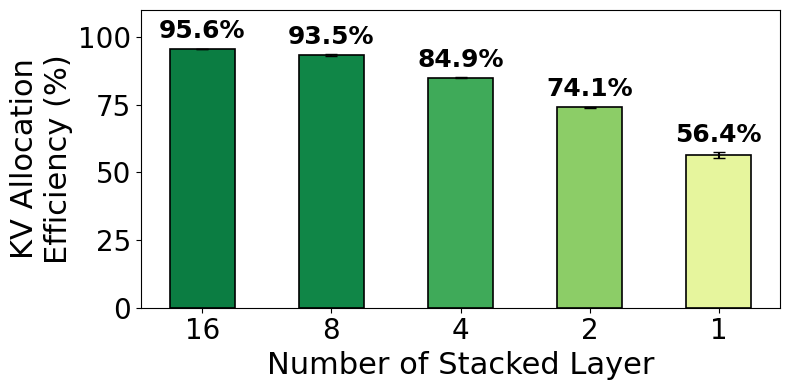


Internal Fragmentation Analysis:
Block Size 32 (granularity=16):  Allocation Efficiency=95.6%,  Memory Waste=4.4%
Block Size 64 (granularity=8):  Allocation Efficiency=93.5%,  Memory Waste=6.5%
Block Size 128 (granularity=4):  Allocation Efficiency=84.9%,  Memory Waste=15.1%
Block Size 256 (granularity=2):  Allocation Efficiency=74.1%,  Memory Waste=25.9%
Block Size 512 (granularity=1):  Allocation Efficiency=56.4%,  Memory Waste=43.6%


In [ ]:

# ==================== 单独绘制 KV Wastage 图 ====================
print("\n" + "=" * 60)
print("KV Wastage")
print("=" * 60)

# 兼容旧的数据列名，避免必须重新运行前面的代码单元
if 'kv_memory_wastage' not in df.columns:
    if 'kv_memory_waste' in df.columns:
        df['kv_memory_wastage'] = df['kv_memory_waste']
    elif 'kv_allocation_efficiency' in df.columns:
        df['kv_memory_wastage'] = 1 - df['kv_allocation_efficiency']
    elif 'kv_memory_utilization' in df.columns:
        df['kv_memory_wastage'] = 1 - df['kv_memory_utilization']
    else:
        raise KeyError(
            "缺少 `kv_memory_wastage` 列，请先重新运行第 1 个代码单元。"
        )

# 字号设置
FONTSIZE_KV_TICK = 20           # 轴刻度标签
FONTSIZE_KV_AXIS = 22           # 轴标题
FONTSIZE_KV_VALUE = 18          # 数值标签

# 按 block_size 聚合（跨所有 request_rate）
df_kv_agg = df.groupby('block_size').agg({
    'kv_memory_wastage': ['mean', 'std']
}).reset_index()
df_kv_agg.columns = ['block_size', 'kv_wastage_mean', 'kv_wastage_std']
df_kv_agg['granularity'] = 512 // df_kv_agg['block_size']
# Number of Stacked Layer 从小到大：1, 2, 4, 8, 16
df_kv_agg = df_kv_agg.sort_values('granularity')

# 过滤掉 NaN 数据 (vmm=0 没有 KV stats)
df_kv_valid = df_kv_agg.dropna(subset=['kv_wastage_mean'])

print(df_kv_agg)
print(f"\n有效数据点: {len(df_kv_valid)}")

# 绘制 KV Wastage 图 - 更扁的布局
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(df_kv_valid))
x_labels = [f'{int(g)}' for g in df_kv_valid['granularity']]  # 从小到大显示 stacked layers
colors = plt.cm.RdYlGn_r(df_kv_valid['kv_wastage_mean'])  # 颜色映射：绿(低)->黄->红(高)

# 更细的柱子
bar_width = 0.5
bars = ax.bar(x, df_kv_valid['kv_wastage_mean'] * 100, 
              width=bar_width,
              yerr=df_kv_valid['kv_wastage_std'] * 100, 
              color=colors, capsize=4, edgecolor='black', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=FONTSIZE_KV_TICK)
ax.set_ylabel('KV Wastage (%)', fontsize=FONTSIZE_KV_AXIS)
ax.set_xlabel('Number of Stacked Layer', fontsize=FONTSIZE_KV_AXIS)
ax.set_ylim(0, 110)
ax.tick_params(axis='y', labelsize=FONTSIZE_KV_TICK)

# 添加数值标签
for i, (mean, std) in enumerate(zip(df_kv_valid['kv_wastage_mean'], df_kv_valid['kv_wastage_std'])):
    ax.text(i, mean * 100 + std * 100 + 2, f'{mean*100:.1f}%', 
            ha='center', va='bottom', fontsize=FONTSIZE_KV_VALUE, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-granularity-kv-wastage.pdf', format='pdf', bbox_inches='tight')
plt.show()

# 打印内部碎片分析
print("\n" + "=" * 60)
print("Internal Fragmentation Analysis:")
print("=" * 60)
for _, row in df_kv_valid.iterrows():
    efficiency = (1 - row['kv_wastage_mean']) * 100
    print(f"Block Size {int(row['block_size'])} (granularity={int(row['granularity'])}): ",
          f"Wastage={row['kv_wastage_mean']*100:.1f}%, ",
          f"Allocation Efficiency={efficiency:.1f}%")